---
title: Ajustando una red profunda
subject: Aprendizaje Profundo
subtitle: 
short_title: Ajustando un red profunda
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---




**Objetivo**: Practicar el entrenamiento de una red neuronal profunda (20 capas) usando el conjunto de datos CIFAR10.

Cuadernillo adaptado de https://github.com/MrMoonKr/hands-on-machine-learning-with-scikit-learn-and-pytorch/blob/main/11_training_deep_neural_networks.ipynb

## Preliminares

In [1]:
import sys

assert sys.version_info >= (3, 10)

In [2]:
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

In [3]:
if IS_COLAB:
    %pip install -q torchmetrics

In [4]:
from packaging.version import Version

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

assert Version(torch.__version__) >= Version("2.6.0")

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [6]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

## Carga de datos

Cargamos el conjunto de datos CIFAR10. Este está compuesto por 60.000 imágenes en color de 32 × 32 píxeles (50.000 para entrenamiento, 10.000 para prueba) con 10 clases.

In [7]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_set = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toTensor)
test_set = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=toTensor)

Como vamos a utilizar parada temprana (early stopping), necesitamos un conjunto de validación. Usemos 5.000 imágenes del conjunto de entrenamiento original como conjunto de validación:

In [8]:
torch.manual_seed(42)
train_set, valid_set = torch.utils.data.random_split(
    train_and_valid_set, [45_000, 5_000])

Y ahora creamos los *dataloaders*

In [9]:
batch_size = 128
train_loader = DataLoader(train_set, batch_size=batch_size)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

## Definiendo la red

Construimos una DNN con 20 capas ocultas de 100 neuronas cada una (**¡¡¡son demasiadas!!!** pero ese es el objetivo de este ejercicio). Usaremos la inicialización He y la función de activación Swish (usando nn.SiLU). Como se trata de una tarea de clasificación, necesitaremos una capa de salida con una neurona por clase.

In [10]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [11]:
def build_deep_model(n_hidden, n_neurons, n_inputs, n_outputs):

    # Definición de una capa
    layers = [nn.Flatten(), nn.Linear(n_inputs, n_neurons), nn.SiLU()]

    # Generación procedural de todas las capas
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SiLU()]

    # Capa de salida
    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [12]:
torch.manual_seed(42)
model = build_deep_model(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

Notar que hemos usado un constructor secuencial para definir la red. Esta es una versión alternativa  a nn.Module que revisamos anteriormente. Como ventaja requiere menos código.
Para más información revisa la documentación:  https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html

## Regularización

Usando la optimización NAdam y parada temprana (early stopping), entrenamos la red en el conjunto de datos CIFAR10.

In [13]:
import time

def train_with_early_stopping(
    model, optimizer, loss_fn, metric, train_loader,
    valid_loader, n_epochs, patience=10,
    checkpoint_path=None, scheduler=None
):
    checkpoint_path = checkpoint_path or "my_checkpoint.pt"
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": [], "valid_losses": []}
    best_metric = 0.0
    patience_counter = 0
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        t0 = time.time()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        train_metric = metric.compute().item()

        # Calculate validation loss and metric
        model.eval()
        total_valid_loss = 0.0
        metric.reset()
        with torch.no_grad():
            for X_batch_val, y_batch_val in valid_loader:
                X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
                y_pred_val = model(X_batch_val)
                loss_val = loss_fn(y_pred_val, y_batch_val)
                total_valid_loss += loss_val.item()
                metric.update(y_pred_val, y_batch_val)

        valid_metric = metric.compute().item()
        avg_valid_loss = total_valid_loss / len(valid_loader)

        if valid_metric > best_metric:
            torch.save(model.state_dict(), checkpoint_path)
            best_metric = valid_metric
            best = " (best)"
            patience_counter = 0
        else:
            patience_counter += 1
            best = ""

        t1 = time.time()
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)
        history["valid_losses"].append(avg_valid_loss) # Store validation loss
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"valid loss: {history['valid_losses'][-1]:.4f}, " # Added valid loss to print
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}{best}"
              f" in {t1 - t0:.1f}s"
        )
        if scheduler is not None:
            scheduler.step()
        if patience_counter >= patience:
            print("Early stopping!")
            break

    model.load_state_dict(torch.load(checkpoint_path))
    return history

Usemos un optimizador NAdam con una tasa de aprendizaje de 2e-3. Puedes probar con otros valores si lo deseas.

In [14]:
optimizer = torch.optim.NAdam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

Ahora realizamos el entrenamiento

In [15]:
n_epochs = 100
history = train_with_early_stopping(
    model, optimizer, criterion, accuracy,train_loader, valid_loader, n_epochs
)

Epoch 1/100, train loss: 2.1743, valid loss: 2.1210, train metric: 0.1644, valid metric: 0.1786 (best) in 13.9s
Epoch 2/100, train loss: 2.0251, valid loss: 2.0145, train metric: 0.2202, valid metric: 0.2406 (best) in 13.6s
Epoch 3/100, train loss: 1.9205, valid loss: 1.9343, train metric: 0.2679, valid metric: 0.2634 (best) in 13.6s
Epoch 4/100, train loss: 2.0932, valid loss: 1.9297, train metric: 0.2575, valid metric: 0.2656 (best) in 14.0s
Epoch 5/100, train loss: 1.8331, valid loss: 1.8428, train metric: 0.3129, valid metric: 0.3068 (best) in 14.2s
Epoch 6/100, train loss: 1.7872, valid loss: 1.8154, train metric: 0.3343, valid metric: 0.3168 (best) in 13.7s
Epoch 7/100, train loss: 1.7739, valid loss: 1.7884, train metric: 0.3452, valid metric: 0.3374 (best) in 16.2s
Epoch 8/100, train loss: 1.7493, valid loss: 1.7956, train metric: 0.3562, valid metric: 0.3332 in 14.0s
Epoch 9/100, train loss: 1.7258, valid loss: 1.9459, train metric: 0.3657, valid metric: 0.3116 in 13.4s
Epoch 

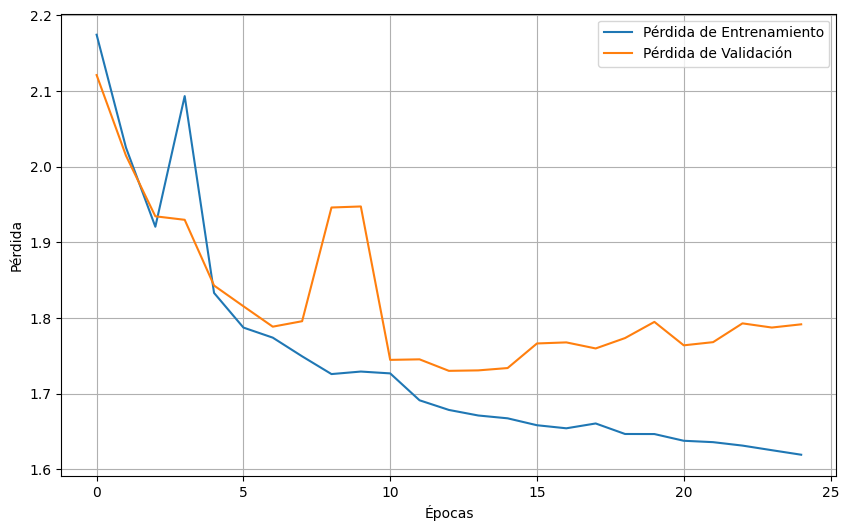

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_losses"], label="Pérdida de Entrenamiento")
plt.plot(history["valid_losses"], label="Pérdida de Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

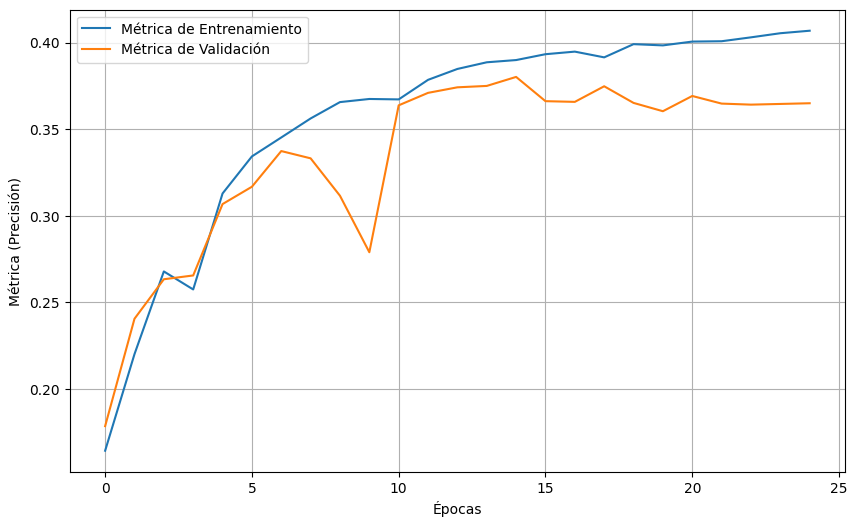

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_metrics"], label="Métrica de Entrenamiento")
plt.plot(history["valid_metrics"], label="Métrica de Validación")
plt.xlabel("Épocas")
plt.ylabel("Métrica (Precisión)")
plt.legend()
plt.grid(True)
plt.show()

El modelo con la menor pérdida de validación obtiene menos del 43% de precisión en el conjunto de validación. Cada época tardó aproximadamente 4 segundos en Colab. Veamos si podemos mejorar el modelo usando Normalización por Lotes (Batch Normalization).

## Normalización por lotes

Ahora agregaremos normalización por lotes (*batch normalization*) y compararemos las curvas de aprendizaje.

In [18]:
def build_deep_model_with_batch_norm(n_hidden, n_neurons, n_inputs, n_outputs):

    layers = [nn.Flatten(), nn.Linear(n_inputs, n_neurons),
              nn.BatchNorm1d(n_neurons), nn.SiLU()]

    # Se generan todas las capas ocultas proceduralmente
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons),
                   nn.BatchNorm1d(n_neurons), nn.SiLU()]

    # Agregamos la capa de salida
    layers += [nn.Linear(n_neurons, n_outputs)]

    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [20]:
torch.manual_seed(42)
model = build_deep_model_with_batch_norm(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

In [21]:
optimizer = torch.optim.NAdam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [22]:
n_epochs = 100
history = train_with_early_stopping(
    model, optimizer, criterion, accuracy,
    train_loader, valid_loader, n_epochs
)

Epoch 1/100, train loss: 1.9239, valid loss: 1.8847, train metric: 0.2956, valid metric: 0.3274 (best) in 15.2s
Epoch 2/100, train loss: 1.6310, valid loss: 1.8461, train metric: 0.4108, valid metric: 0.3422 (best) in 15.2s
Epoch 3/100, train loss: 1.5102, valid loss: 1.8971, train metric: 0.4570, valid metric: 0.3444 (best) in 14.8s
Epoch 4/100, train loss: 1.4245, valid loss: 1.8638, train metric: 0.4909, valid metric: 0.3702 (best) in 14.9s
Epoch 5/100, train loss: 1.3555, valid loss: 1.7315, train metric: 0.5191, valid metric: 0.3960 (best) in 15.8s
Epoch 6/100, train loss: 1.2951, valid loss: 1.7367, train metric: 0.5411, valid metric: 0.4008 (best) in 17.4s
Epoch 7/100, train loss: 1.2437, valid loss: 1.7950, train metric: 0.5605, valid metric: 0.3852 in 15.8s
Epoch 8/100, train loss: 1.1990, valid loss: 2.0094, train metric: 0.5760, valid metric: 0.3650 in 17.4s
Epoch 9/100, train loss: 1.1582, valid loss: 1.9673, train metric: 0.5908, valid metric: 0.3780 in 15.7s
Epoch 10/100,

Este gráfico muestra cómo evolucionaron la métrica (precisión) en los conjuntos de entrenamiento y validación a lo largo de las épocas.

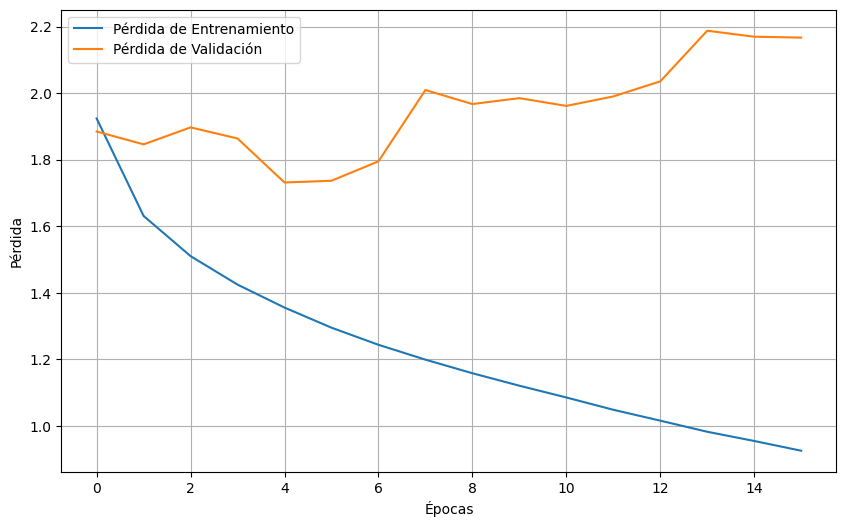

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_losses"], label="Pérdida de Entrenamiento")
plt.plot(history["valid_losses"], label="Pérdida de Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

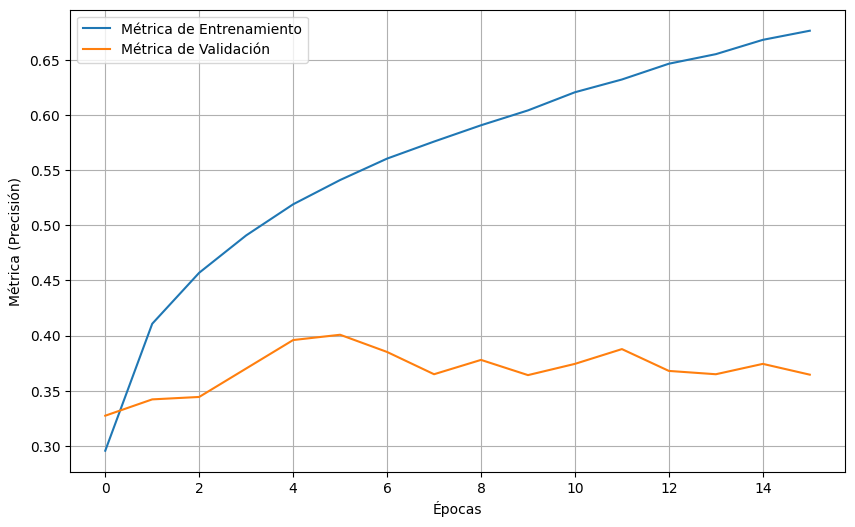

In [28]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_metrics"], label="Métrica de Entrenamiento")
plt.plot(history["valid_metrics"], label="Métrica de Validación")
plt.xlabel("Épocas")
plt.ylabel("Métrica (Precisión)")
plt.legend()
plt.grid(True)
plt.show()

Responde las siguientes preguntas:
- ¿converge más rápido que antes?
- ¿Produce un mejor modelo?
- ¿Cómo afecta la velocidad de entrenamiento?

## Incluyendo Dropout

Ahora, agregaremos la regularización del modelo con alpha dropout. Luego, sin volver a entrenar tu modelo, comprobamos si podemos lograr una mayor precisión usando MC dropout.

In [29]:
def build_deep_model_with_alpha_dropout(n_hidden, n_neurons, n_inputs,
                                        n_outputs, dropout_rate):
    # Definición de cada capa
    layers = [nn.Flatten(),
              nn.Linear(n_inputs, n_neurons), nn.SELU(),
              nn.AlphaDropout(dropout_rate)]

    # Generar las capas ocultas proceduralmente
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SELU(),
                   nn.AlphaDropout(dropout_rate)]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [30]:
torch.manual_seed(42)
model = build_deep_model_with_alpha_dropout(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10,
    dropout_rate=0.1
).to(device)

In [31]:
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [32]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

Epoch 1/100, train loss: 2.6700, valid loss: 2.4690, train metric: 0.0996, valid metric: 0.0760 (best) in 15.9s
Epoch 2/100, train loss: 2.3153, valid loss: 2.3147, train metric: 0.0990, valid metric: 0.1064 (best) in 16.5s
Epoch 3/100, train loss: 2.3112, valid loss: 2.3133, train metric: 0.0997, valid metric: 0.1064 in 15.5s
Epoch 4/100, train loss: 2.3102, valid loss: 2.3129, train metric: 0.0975, valid metric: 0.1064 in 14.7s
Epoch 5/100, train loss: 2.3100, valid loss: 3.6951, train metric: 0.0989, valid metric: 0.0976 in 14.7s
Epoch 6/100, train loss: 2.3097, valid loss: 2.4207, train metric: 0.1001, valid metric: 0.1016 in 15.6s
Epoch 7/100, train loss: 2.3095, valid loss: 4.5190, train metric: 0.0998, valid metric: 0.0976 in 14.6s
Epoch 8/100, train loss: 2.2459, valid loss: 6.7423, train metric: 0.1328, valid metric: 0.1358 (best) in 14.3s
Epoch 9/100, train loss: 2.1159, valid loss: 4.4478, train metric: 0.1714, valid metric: 0.1460 (best) in 14.3s
Epoch 10/100, train loss: 2

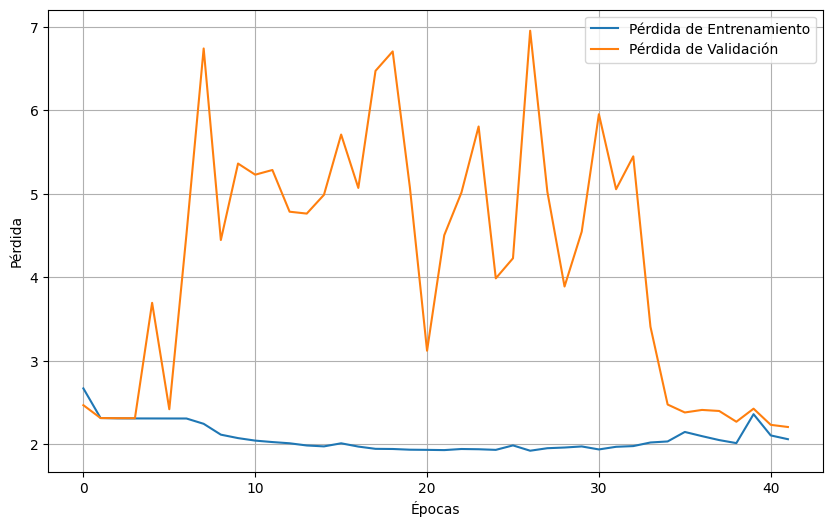

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_losses"], label="Pérdida de Entrenamiento")
plt.plot(history["valid_losses"], label="Pérdida de Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True)
plt.show()

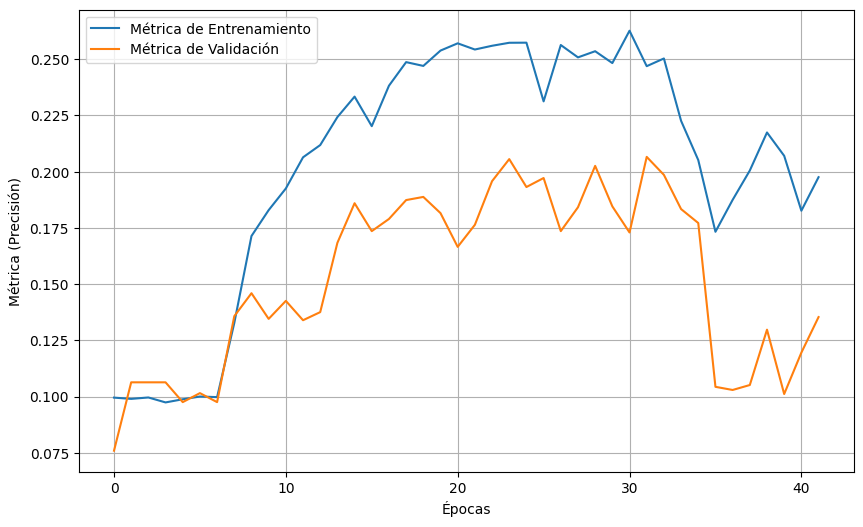

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_metrics"], label="Métrica de Entrenamiento")
plt.plot(history["valid_metrics"], label="Métrica de Validación")
plt.xlabel("Épocas")
plt.ylabel("Métrica (Precisión)")
plt.legend()
plt.grid(True)
plt.show()

Responde las siguientes preguntas:

- ¿Cuál de todas las redes fue la mejor?
- ¿La regularización ayudó a mejorar la generalización del modelo?
